<a href="https://colab.research.google.com/github/ishikabeniwal/CSET343/blob/main/Assignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

In [2]:
df = pd.read_csv("heart.csv")

print(df.head())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   69    0   0       129   188    0        0       97      0      3.7      0   
1   43    0   1       177   305    1        0      185      1      5.0      0   
2   50    1   1       121   321    1        0       94      1      0.6      1   
3   63    0   3       104   267    1        2      163      0      4.4      0   
4   43    0   3       129   242    1        0      165      1      1.3      1   

   ca  thal  target  
0   0     3       0  
1   1     7       1  
2   2     3       1  
3   1     6       0  
4   0     7       0  


In [3]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Number of rows: 50
Number of columns: 14

Data Types:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

Missing Values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [4]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       50 non-null     int64  
 1   sex       50 non-null     int64  
 2   cp        50 non-null     int64  
 3   trestbps  50 non-null     int64  
 4   chol      50 non-null     int64  
 5   fbs       50 non-null     int64  
 6   restecg   50 non-null     int64  
 7   thalach   50 non-null     int64  
 8   exang     50 non-null     int64  
 9   oldpeak   50 non-null     float64
 10  slope     50 non-null     int64  
 11  ca        50 non-null     int64  
 12  thal      50 non-null     int64  
 13  target    50 non-null     int64  
dtypes: float64(1), int64(13)
memory usage: 5.6 KB
None
             age        sex        cp    trestbps        chol        fbs  \
count  50.000000  50.000000  50.00000   50.000000   50.000000  50.000000   
mean   53.220000   0.500000   1.48000  135.720000  236.860000   0

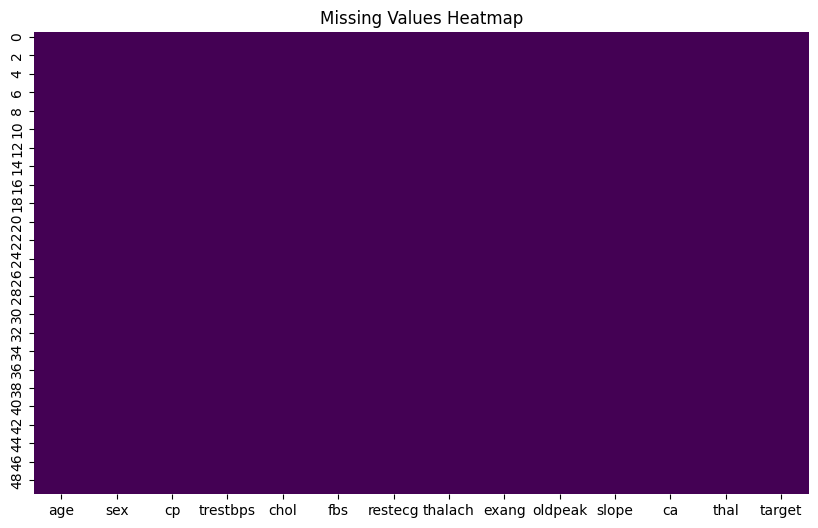

In [5]:
plt.figure(figsize=(10, 6))

sns.heatmap(df.isnull(), cbar=False, cmap="viridis")

plt.title("Missing Values Heatmap")
plt.show()

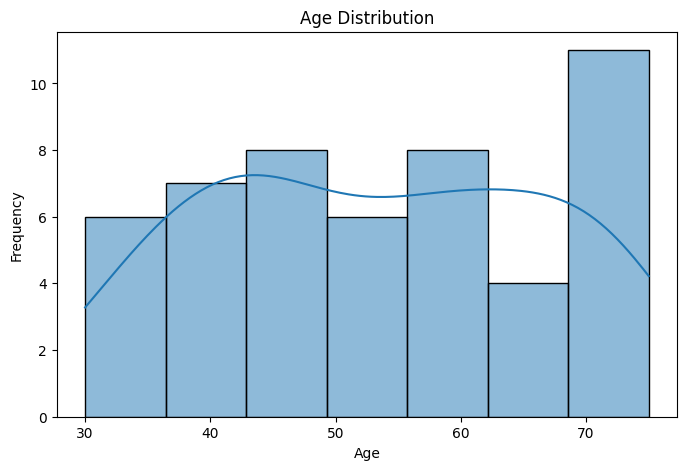

In [6]:
plt.figure(figsize=(8, 5))

sns.histplot(df["age"], kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

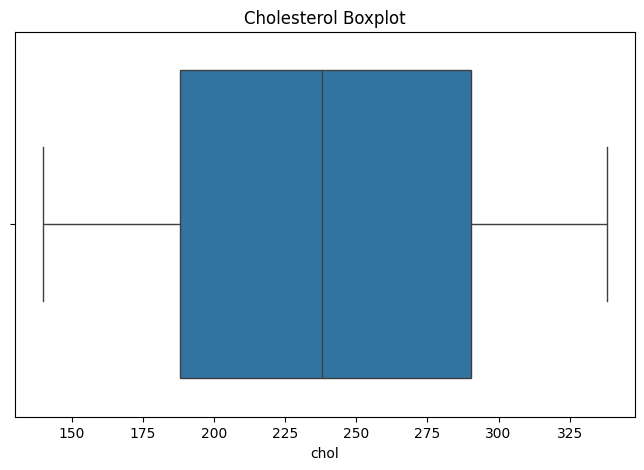

In [11]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=df["chol"])

plt.title("Cholesterol Boxplot")

plt.show()

In [12]:
numerical_columns = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

for column in numerical_columns:
    df[column] = df[column].fillna(df[column].median())

In [13]:
categorical_columns = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal"
]

for column in categorical_columns:
    df[column] = df[column].fillna(df[column].mode()[0])

In [14]:
numerical_columns = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

for column in numerical_columns:

    # Remove missing values temporarily
    values = df[column].dropna().tolist()

    # Sort values
    values.sort()

    # Number of values
    n = len(values)

    # Find Q1 and Q3 manually
    Q1 = values[n // 4]
    Q3 = values[(3 * n) // 4]

    # Calculate IQR
    IQR = Q3 - Q1

    # Calculate limits
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    print("\nColumn:", column)
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower Limit:", lower_limit)
    print("Upper Limit:", upper_limit)

    # Remove outliers manually
    cleaned_values = []

    for value in df[column]:

        if pd.isna(value):
            cleaned_values.append(value)

        elif value >= lower_limit and value <= upper_limit:
            cleaned_values.append(value)

        else:
            cleaned_values.append(np.nan)

    df[column] = cleaned_values


Column: age
Q1: 42
Q3: 64
IQR: 22
Lower Limit: 9.0
Upper Limit: 97.0

Column: trestbps
Q1: 118
Q3: 152
IQR: 34
Lower Limit: 67.0
Upper Limit: 203.0

Column: chol
Q1: 188
Q3: 292
IQR: 104
Lower Limit: 32.0
Upper Limit: 448.0

Column: thalach
Q1: 100
Q3: 163
IQR: 63
Lower Limit: 5.5
Upper Limit: 257.5

Column: oldpeak
Q1: 1.7
Q3: 4.8
IQR: 3.0999999999999996
Lower Limit: -2.9499999999999993
Upper Limit: 9.45


In [15]:
for column in numerical_columns:
    df[column] = df[column].fillna(df[column].median())

In [16]:
print("Negative age values:")
print(df[df["age"] < 0])

Negative age values:
Empty DataFrame
Columns: [age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal, target]
Index: []


In [17]:
df.loc[df["age"] < 0, "age"] = df["age"].median()

In [18]:
print("Negative values in trestbps:")
print(df[df["trestbps"] < 0])

print("Negative values in chol:")
print(df[df["chol"] < 0])

print("Negative values in thalach:")
print(df[df["thalach"] < 0])

Negative values in trestbps:
Empty DataFrame
Columns: [age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal, target]
Index: []
Negative values in chol:
Empty DataFrame
Columns: [age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal, target]
Index: []
Negative values in thalach:
Empty DataFrame
Columns: [age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal, target]
Index: []


In [19]:
df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 40, 60, np.inf],
    labels=["<40", "40-60", ">60"],
    right=False
)

print(df[["age", "age_group"]].head())

   age age_group
0   69       >60
1   43     40-60
2   50     40-60
3   63       >60
4   43     40-60


In [20]:
df["risk_score"] = df["age"] * df["chol"]

In [21]:
minimum = df["risk_score"].min()
maximum = df["risk_score"].max()

df["risk_score"] = (
    (df["risk_score"] - minimum) /
    (maximum - minimum)
)

print(df[["age", "chol", "risk_score"]].head())

   age  chol  risk_score
0   69   188    0.461096
1   43   305    0.469493
2   50   321    0.641846
3   63   267    0.687122
4   43   242    0.310412


In [22]:
categorical_columns = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal",
    "age_group"
]

df = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=True
)

print(df.head())

   age  trestbps  chol  thalach  oldpeak  target  risk_score  sex_1   cp_1  \
0   69       129   188       97      3.7       0    0.461096  False  False   
1   43       177   305      185      5.0       1    0.469493  False   True   
2   50       121   321       94      0.6       1    0.641846   True   True   
3   63       104   267      163      4.4       0    0.687122  False  False   
4   43       129   242      165      1.3       0    0.310412  False  False   

    cp_2  ...  exang_1  slope_1  slope_2   ca_1   ca_2   ca_3  thal_6  thal_7  \
0  False  ...    False    False    False  False  False  False   False   False   
1  False  ...     True    False    False   True  False  False   False    True   
2  False  ...     True     True    False  False   True  False   False   False   
3  False  ...    False    False    False   True  False  False    True   False   
4  False  ...     True     True    False  False  False  False   False    True   

   age_group_40-60  age_group_>60  
0       

In [23]:
columns_to_scale = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

scaler = MinMaxScaler()

df[columns_to_scale] = scaler.fit_transform(
    df[columns_to_scale]
)

print(df.head())

        age  trestbps      chol   thalach   oldpeak  target  risk_score  \
0  0.866667    0.3625  0.242424  0.204724  0.596491       0    0.461096   
1  0.288889    0.9625  0.833333  0.897638  0.824561       1    0.469493   
2  0.444444    0.2625  0.914141  0.181102  0.052632       1    0.641846   
3  0.733333    0.0500  0.641414  0.724409  0.719298       0    0.687122   
4  0.288889    0.3625  0.515152  0.740157  0.175439       0    0.310412   

   sex_1   cp_1   cp_2  ...  exang_1  slope_1  slope_2   ca_1   ca_2   ca_3  \
0  False  False  False  ...    False    False    False  False  False  False   
1  False   True  False  ...     True    False    False   True  False  False   
2   True   True  False  ...     True     True    False  False   True  False   
3  False  False  False  ...    False    False    False   True  False  False   
4  False  False  False  ...     True     True    False  False  False  False   

   thal_6  thal_7  age_group_40-60  age_group_>60  
0   False   False     

In [24]:
original_df = df.copy()

In [25]:
print("BEFORE CLEANING")
print(original_df[[
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]].describe())

BEFORE CLEANING
             age   trestbps       chol    thalach    oldpeak
count  50.000000  50.000000  50.000000  50.000000  50.000000
mean    0.516000   0.446500   0.489192   0.457638   0.536491
std     0.298693   0.311197   0.297906   0.288757   0.305293
min     0.000000   0.000000   0.000000   0.000000   0.000000
25%     0.272222   0.228125   0.242424   0.232283   0.258772
50%     0.511111   0.375000   0.494949   0.444882   0.605263
75%     0.750000   0.650000   0.758838   0.714567   0.785088
max     1.000000   1.000000   1.000000   1.000000   1.000000


In [26]:
print("AFTER CLEANING")
print(df[[
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]].describe())

AFTER CLEANING
             age   trestbps       chol    thalach    oldpeak
count  50.000000  50.000000  50.000000  50.000000  50.000000
mean    0.516000   0.446500   0.489192   0.457638   0.536491
std     0.298693   0.311197   0.297906   0.288757   0.305293
min     0.000000   0.000000   0.000000   0.000000   0.000000
25%     0.272222   0.228125   0.242424   0.232283   0.258772
50%     0.511111   0.375000   0.494949   0.444882   0.605263
75%     0.750000   0.650000   0.758838   0.714567   0.785088
max     1.000000   1.000000   1.000000   1.000000   1.000000


In [27]:
print("Mean:")
print(df[columns_to_scale].mean())

print("\nMedian:")
print(df[columns_to_scale].median())

print("\nStandard Deviation:")
print(df[columns_to_scale].std())

Mean:
age         0.516000
trestbps    0.446500
chol        0.489192
thalach     0.457638
oldpeak     0.536491
dtype: float64

Median:
age         0.511111
trestbps    0.375000
chol        0.494949
thalach     0.444882
oldpeak     0.605263
dtype: float64

Standard Deviation:
age         0.298693
trestbps    0.311197
chol        0.297906
thalach     0.288757
oldpeak     0.305293
dtype: float64


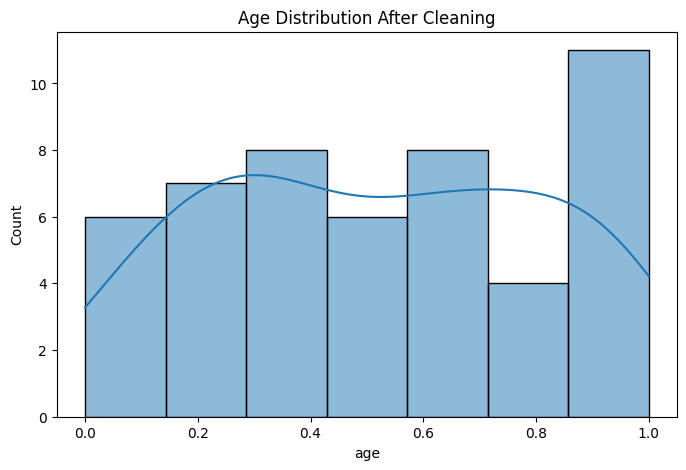

In [28]:
plt.figure(figsize=(8, 5))

sns.histplot(df["age"], kde=True)

plt.title("Age Distribution After Cleaning")

plt.show()

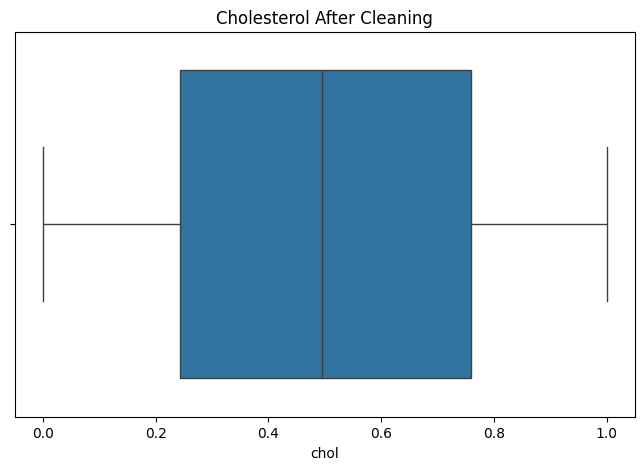

In [29]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=df["chol"])

plt.title("Cholesterol After Cleaning")

plt.show()

In [30]:
print("Missing values after cleaning:")

print(df.isnull().sum())

Missing values after cleaning:
age                0
trestbps           0
chol               0
thalach            0
oldpeak            0
target             0
risk_score         0
sex_1              0
cp_1               0
cp_2               0
cp_3               0
fbs_1              0
restecg_1          0
restecg_2          0
exang_1            0
slope_1            0
slope_2            0
ca_1               0
ca_2               0
ca_3               0
thal_6             0
thal_7             0
age_group_40-60    0
age_group_>60      0
dtype: int64


In [31]:
print(
    "Total missing values:",
    df.isnull().sum().sum()
)

Total missing values: 0
